In [1]:
import os
import random
import re
import itertools
import math
import hashlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from collections import defaultdict, Counter
from matplotlib.lines import Line2D
from collections import Counter
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
seed_string = 'NLP'
digest = hashlib.sha256(seed_string.encode("utf-8")).digest()
SEED = int.from_bytes(digest[:1], "big")
print(SEED)

179


In [4]:
def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

# Utils

## Tokens

In [5]:
def tokenize(text):
    text = text.lower()
    return re.findall(r"[a-zA-Z]+(?:['’-][a-zA-Z]+)*|[^\w\s]", text)

def tokenize_rows_with_eos(series):
    tokens = []
    for row in series.astype(str):
        row_tokens = tokenize(row)
        if row_tokens:
            tokens.extend(row_tokens)
            tokens.append("<eos>")
    return tokens

In [6]:
def encode(tokens):
    return [stoi.get(tok, stoi["<unk>"]) for tok in tokens]


In [7]:
def make_windows(token_ids, context_size):
    X, y = [], []
    for i in range(context_size, len(token_ids)):
        X.append(token_ids[i-context_size:i])
        y.append(token_ids[i])
    return X, y

## Datasets

In [8]:
def make_loaders(train_ds, val_ds, test_ds, seed=42):
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
        torch.manual_seed(worker_seed)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=128, shuffle=True,
        num_workers=0, worker_init_fn=seed_worker, generator=g
    )
    val_loader = DataLoader(
        val_ds, batch_size=256, shuffle=False,
        num_workers=0, worker_init_fn=seed_worker, generator=g
    )
    test_loader = DataLoader(
        test_ds, batch_size=256, shuffle=False,
        num_workers=0, worker_init_fn=seed_worker, generator=g
    )
    return train_loader, val_loader, test_loader

## Models training

In [9]:
def evaluate(model, loader, criterion, device):
    model.eval()
    losses = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)
            losses.append(loss.item())

    mean_loss = float(np.mean(losses))
    ppl = float(np.exp(mean_loss))
    return mean_loss, ppl

In [10]:
def train_model(model, train_loader, val_loader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_ppl": [],
        "val_loss": [],
        "val_ppl": [],
    }

    best_state = None
    best_val_loss = float("inf")

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        train_ppl = float(np.exp(train_loss))
        val_loss, val_ppl = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_ppl"].append(train_ppl)
        history["val_loss"].append(val_loss)
        history["val_ppl"].append(val_ppl)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"train loss={train_loss:.4f} ppl={train_ppl:.2f} | "
            f"val loss={val_loss:.4f} ppl={val_ppl:.2f}"
        )

    model.load_state_dict(best_state)
    return model, history

## Experiments

In [11]:
def run_single_experiment(
    model_name,
    build_model_fn,
    train_fn,
    emb_dim,
    hidden_dim,
    dropout,
    device,
    seed,
):
    set_seed(seed)
    train_loader, val_loader, test_loader = make_loaders(
        train_ds, val_ds, test_ds, seed=seed
    )

    model = build_model_fn(
        emb_dim=emb_dim,
        hidden_dim=hidden_dim,
        dropout=dropout,
    ).to(device)

    model, history = train_fn(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS,
        lr=LR,
        device=device,
    )

    criterion = nn.CrossEntropyLoss()
    test_loss, test_ppl = evaluate(model, test_loader, criterion, device)

    best_epoch = int(np.argmin(history["val_ppl"]) + 1)

    result = {
        "model": model_name,
        "emb_dim": emb_dim,
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "best_epoch": best_epoch,
        "best_val_loss": float(np.min(history["val_loss"])),
        "best_val_ppl": float(np.min(history["val_ppl"])),
        "test_loss": float(test_loss),
        "test_ppl": float(test_ppl),
    }

    return model, history, result


def run_grid_search(
    model_name,
    build_model_fn,
    train_fn,
    emb_dims,
    hidden_dims,
    dropouts,
    device,
    seed,
):
    results = []
    all_histories = {}

    best_model = None
    best_history = None
    best_row = None

    for emb_dim, hidden_dim, dropout in itertools.product(emb_dims, hidden_dims, dropouts):
        print("=" * 80)
        print(
            f"{model_name} | emb_dim={emb_dim}, "
            f"hidden_dim={hidden_dim}, dropout={dropout}"
        )

        model, history, result = run_single_experiment(
            model_name=model_name,
            build_model_fn=build_model_fn,
            train_fn=train_fn,
            emb_dim=emb_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
            device=device,
            seed=seed,
        )

        config_key = (emb_dim, hidden_dim, dropout)

        results.append(result)
        all_histories[config_key] = history

        print(
            f"best_epoch={result['best_epoch']} | "
            f"best_val_ppl={result['best_val_ppl']:.4f} | "
            f"test_ppl={result['test_ppl']:.4f}"
        )

        if best_row is None or result["best_val_ppl"] < best_row["best_val_ppl"]:
            best_model = model
            best_history = history
            best_row = result

    results_df = (
        pd.DataFrame(results)
        .sort_values(["best_val_ppl", "test_ppl"])
        .reset_index(drop=True)
    )

    return {
        "results_df": results_df,
        "all_histories": all_histories,
        "best_model": best_model,
        "best_history": best_history,
        "best_row": best_row,
    }

# Data saving and loading

In [12]:
def save_search(search, model_name, path):
    payload = {
        "model_name": model_name,
        "results_df": search["results_df"].to_dict(orient="records"),
        "results_columns": list(search["results_df"].columns),
        "all_histories": search["all_histories"],
        "best_row": search["best_row"],
        "best_history": search["best_history"],
        "best_model_state_dict": {
            k: v.detach().cpu()
            for k, v in search["best_model"].state_dict().items()
        },
    }
    torch.save(payload, path)

def load_search(path, build_model_fn, device="cpu"):
    payload = torch.load(path, map_location=device)

    results_df = pd.DataFrame(payload["results_df"])
    if "results_columns" in payload:
        results_df = results_df[payload["results_columns"]]

    best_row = payload["best_row"]

    best_model = build_model_fn(
        emb_dim=best_row["emb_dim"],
        hidden_dim=best_row["hidden_dim"],
        dropout=best_row["dropout"],
    ).to(device)

    best_model.load_state_dict(payload["best_model_state_dict"])
    best_model.eval()

    search = {
        "results_df": results_df,
        "all_histories": payload["all_histories"],
        "best_model": best_model,
        "best_history": payload["best_history"],
        "best_row": best_row,
    }
    return search

# Plotting

In [13]:
def build_history_summary(search):
    rows = []

    for (emb_dim, hidden_dim, dropout), history in search["all_histories"].items():
        train_ppl = np.array(history["train_ppl"], dtype=float)
        val_ppl = np.array(history["val_ppl"], dtype=float)

        best_idx = int(np.argmin(val_ppl))
        min_val_ppl = float(val_ppl[best_idx])

        row = {
            "emb_dim": emb_dim,
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "best_epoch": best_idx + 1,
            "min_val_ppl": min_val_ppl,
            "train_ppl_at_best": float(train_ppl[best_idx]),
            "val_ppl_at_best": float(val_ppl[best_idx]),
            "gap_at_best": float(val_ppl[best_idx] - train_ppl[best_idx]),
            "final_train_ppl": float(train_ppl[-1]),
            "final_val_ppl": float(val_ppl[-1]),
            "final_gap": float(val_ppl[-1] - train_ppl[-1]),
            "overfit_score": float(max(val_ppl[-1] - min_val_ppl, 0.0)),
        }
        rows.append(row)

    summary = (
        pd.DataFrame(rows)
        .sort_values(["min_val_ppl", "overfit_score", "gap_at_best"])
        .reset_index(drop=True)
    )
    return summary

In [14]:
def plot_learning_curves(search, model_name, top_n=None):
    results_df = search["results_df"]
    all_histories = search["all_histories"]

    configs = list(
        zip(
            results_df["emb_dim"],
            results_df["hidden_dim"],
            results_df["dropout"],
        )
    )

    if top_n is not None:
        configs = configs[:top_n]

    curves = []
    for config in configs:
        emb_dim, hidden_dim, dropout = config
        history = all_histories[config]

        val_ppl = np.asarray(history["val_ppl"], dtype=float)
        epochs = np.arange(1, len(val_ppl) + 1)

        best_idx = int(np.argmin(val_ppl))
        best_epoch = best_idx + 1
        best_val_ppl = float(val_ppl[best_idx])
        max_val_ppl = float(np.max(val_ppl))

        label = (
            f"emb={emb_dim}, hid={hidden_dim}, drop={dropout} | "
            f"min={best_val_ppl:.2f} @ ep {best_epoch}"
        )

        curves.append({
            "config": config,
            "epochs": epochs,
            "val_ppl": val_ppl,
            "best_epoch": best_epoch,
            "best_val_ppl": best_val_ppl,
            "max_val_ppl": max_val_ppl,
            "label": label,
        })

    curves.sort(key=lambda x: x["max_val_ppl"], reverse=True)

    plt.figure(figsize=(10, 6))

    handles = []
    labels = []

    for curve in curves:
        line, = plt.plot(
            curve["epochs"],
            curve["val_ppl"],
            linewidth=1.8,
            label=curve["label"]
        )
        plt.scatter(
            curve["best_epoch"],
            curve["best_val_ppl"],
            s=25,
            zorder=3,
            color=line.get_color()
        )

        handles.append(line)
        labels.append(curve["label"])

    plt.xlabel("Epoch")
    plt.ylabel("Validation Perplexity")
    plt.title(f"{model_name}: validation perplexity by configuration")
    plt.grid(alpha=0.2)
    plt.legend(
        handles,
        labels,
        frameon=False,
        fontsize=8,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()

In [15]:
def plot_metric_heatmaps_3d(summary, model_name):
    metrics = [
        ("min_val_ppl", "Minimum validation perplexity"),
        ("overfit_score", "Overfitting score"),
    ]

    emb_vals = sorted(summary["emb_dim"].unique())
    hid_vals = sorted(summary["hidden_dim"].unique())
    drop_vals = sorted(summary["dropout"].unique())

    emb_to_idx = {v: i for i, v in enumerate(emb_vals)}
    hid_to_idx = {v: i for i, v in enumerate(hid_vals)}
    drop_to_idx = {v: i for i, v in enumerate(drop_vals)}

    fig = plt.figure(figsize=(14, 6))
    for plot_idx, (metric, title) in enumerate(metrics, start=1):
        ax = fig.add_subplot(1, 2, plot_idx, projection="3d")

        values = summary[metric].to_numpy(dtype=float)
        norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
        cmap = cm.viridis

        xs = []
        ys = []
        zs = []
        dx = []
        dy = []
        dz = []
        colors = []

        for _, row in summary.iterrows():
            x = emb_to_idx[row["emb_dim"]]
            y = hid_to_idx[row["hidden_dim"]]
            z = drop_to_idx[row["dropout"]]

            xs.append(x - 0.3)
            ys.append(y - 0.3)
            zs.append(z - 0.3)

            dx.append(0.6)
            dy.append(0.6)
            dz.append(0.6)

            colors.append(cmap(norm(row[metric])))

        ax.bar3d(
            xs, ys, zs,
            dx, dy, dz,
            color=colors,
            shade=True,
            alpha=0.95
        )

        ax.set_xticks(range(len(emb_vals)))
        ax.set_yticks(range(len(hid_vals)))
        ax.set_zticks(range(len(drop_vals)))

        ax.set_xticklabels(emb_vals)
        ax.set_yticklabels(hid_vals)
        ax.set_zticklabels(drop_vals)

        ax.set_xlabel("emb_dim")
        ax.set_ylabel("hidden_dim")
        ax.set_zlabel("dropout")
        ax.set_title(title)

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, shrink=0.75, pad=0.08)
        cbar.set_label(metric)

        ax.view_init(elev=24, azim=-58)

# Load data

In [16]:
splits = {'train': 'train.csv', 'test': 'test.csv'}
train_df = pd.read_csv("hf://datasets/Trelis/tiny-shakespeare/" + splits["train"])
test_df = pd.read_csv("hf://datasets/Trelis/tiny-shakespeare/" + splits["test"])

# Tokenization

In [17]:
split_idx = int(0.9 * len(train_df))

train_rows = train_df["Text"].iloc[:split_idx]
val_rows = train_df["Text"].iloc[split_idx:]

train_tokens = tokenize_rows_with_eos(train_rows)
val_tokens = tokenize_rows_with_eos(val_rows)
test_tokens = tokenize_rows_with_eos(test_df["Text"])

# Vocabulary

In [18]:
counter = Counter(train_tokens)
min_freq = 2

vocab = ["<pad>", "<unk>"] + [w for w, c in counter.items() if c >= min_freq]
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}

In [19]:
train_ids = encode(train_tokens)
val_ids = encode(val_tokens)
test_ids = encode(test_tokens)

vocab_size = len(vocab)
vocab_size

7107

In [20]:
context_size = 4

X_train, y_train = make_windows(train_ids, context_size)
X_val, y_val = make_windows(val_ids, context_size)
X_test, y_test = make_windows(test_ids, context_size)

# NGram Model

In [21]:
class NGramLM:
    def __init__(self, n=4, k=0.1):
        self.n = n
        self.k = k
        self.context_counts = defaultdict(Counter)
        self.vocab_size = 0

    def fit(self, tokens):
        self.vocab = sorted(set(tokens))
        self.vocab_size = len(self.vocab)

        for i in range(self.n - 1, len(tokens)):
            context = tuple(tokens[i-self.n+1:i])
            target = tokens[i]
            self.context_counts[context][target] += 1

    def prob(self, context, word):
        counts = self.context_counts.get(tuple(context), Counter())
        total = sum(counts.values())
        return (counts[word] + self.k) / (total + self.k * self.vocab_size)

    def perplexity(self, tokens):
        log_prob = 0.0
        n_preds = 0

        for i in range(self.n - 1, len(tokens)):
            context = tokens[i-self.n+1:i]
            target = tokens[i]
            p = self.prob(context, target)
            log_prob += math.log(p)
            n_preds += 1

        return math.exp(-log_prob / n_preds)

In [22]:
ngram = NGramLM(n=2, k=0.1)
ngram.fit(train_tokens)

train_ppl_ngram = ngram.perplexity(train_tokens)
val_ppl_ngram = ngram.perplexity(val_tokens)
test_ppl_ngram = ngram.perplexity(test_tokens)

train_ppl_ngram, val_ppl_ngram, test_ppl_ngram

(268.07377316629714, 811.0037137057681, 1112.8272357084368)

# Dataset making

In [23]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = WindowDataset(X_train, y_train)
val_ds = WindowDataset(X_val, y_val)
test_ds = WindowDataset(X_test, y_test)

# Networks models

In [24]:
class MLPWordLM(nn.Module):
    def __init__(self, vocab_size, emb_dim, context_size, hidden_dim, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.net = nn.Sequential(
            nn.Linear(context_size * emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, vocab_size)
        )

    def forward(self, x):
        emb = self.emb(x)
        emb = emb.view(x.size(0), -1)
        return self.net(emb)

In [25]:
class LSTMWordLM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.emb(x)
        out, _ = self.lstm(emb)
        last = out[:, -1, :]
        last = self.dropout(last)
        return self.fc(last)

# Experiments

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [27]:
EPOCHS = 10
LR = 1e-3

emb_dims = [64, 128]
hidden_dims = [128, 256]
dropouts = [0.1, 0.3, 0.5]

In [28]:
def build_mlp(emb_dim, hidden_dim, dropout):
    return MLPWordLM(
        vocab_size=vocab_size,
        emb_dim=emb_dim,
        context_size=context_size,
        hidden_dim=hidden_dim,
        dropout=dropout
    )

def build_lstm(emb_dim, hidden_dim, dropout):
    return LSTMWordLM(
        vocab_size=vocab_size,
        emb_dim=emb_dim,
        hidden_dim=hidden_dim,
        num_layers=1,
        dropout=dropout
    )

In [29]:
mlp_search = load_search(
    path="mlp_search.pt",
    build_model_fn=build_mlp,
    device=device,
)

lstm_search = load_search(
    path="lstm_search.pt",
    build_model_fn=build_lstm,
    device=device,
)

In [30]:
mlp_summary = build_history_summary(mlp_search)
lstm_summary = build_history_summary(lstm_search)

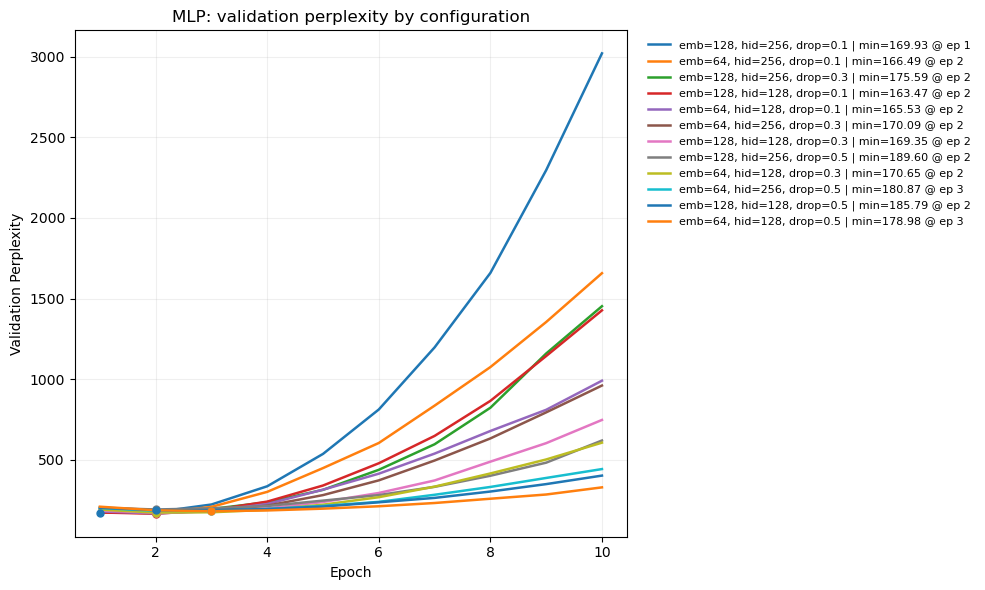

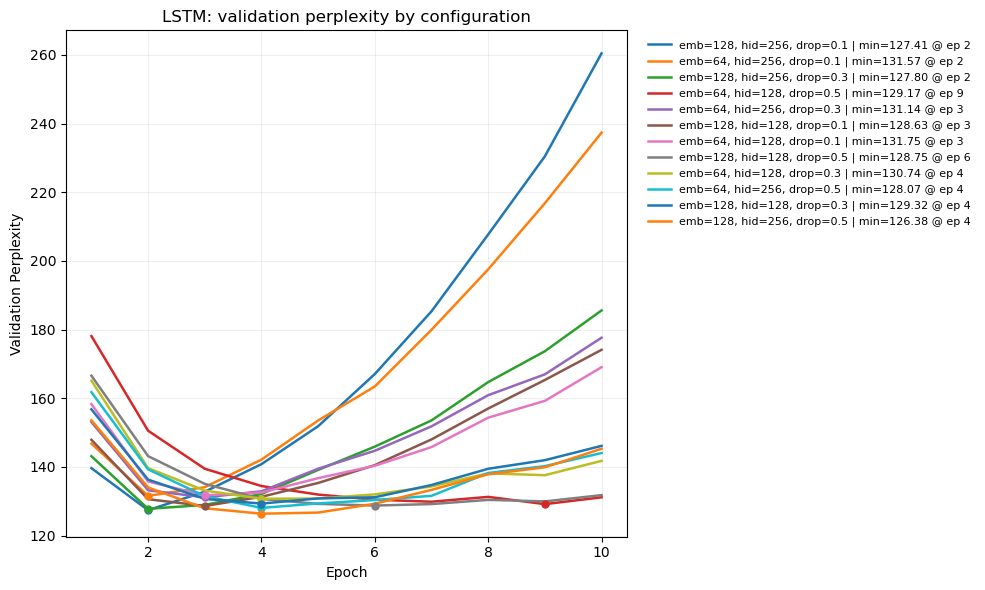

In [31]:
plot_learning_curves(mlp_search, "MLP")
plot_learning_curves(lstm_search, "LSTM")

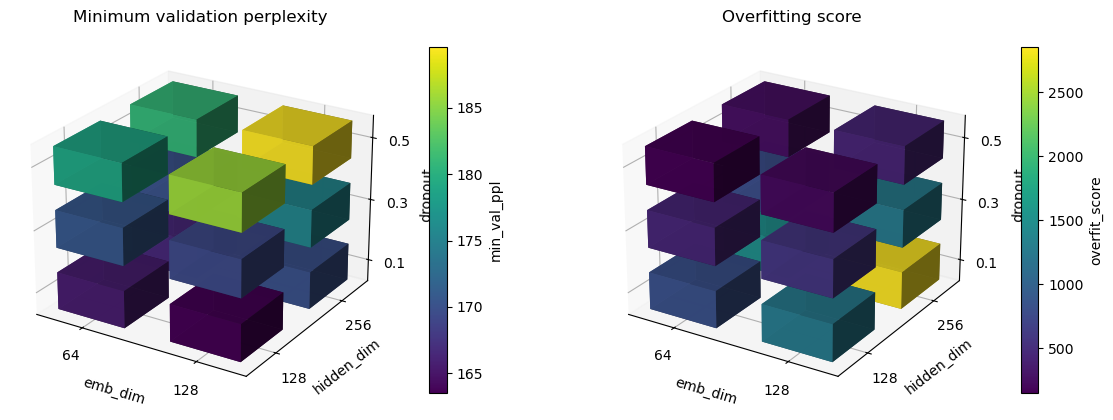

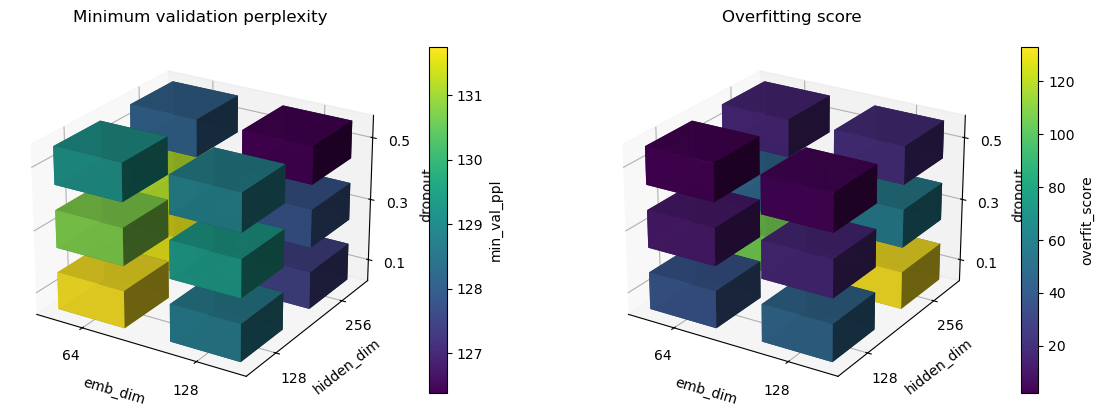

In [32]:
plot_metric_heatmaps_3d(mlp_summary, "MLP")
plot_metric_heatmaps_3d(lstm_summary, "LSTM")

In [39]:
mlp_summary.sort_values(['hidden_dim', 'emb_dim', 'dropout'], ascending=[False, False, True])

,emb_dim,hidden_dim,dropout,best_epoch,min_val_ppl,train_ppl_at_best,val_ppl_at_best,gap_at_best,final_train_ppl,final_val_ppl,final_gap,overfit_score
4,128,256,0.1,1,169.930994,254.942241,169.930994,-85.011247,13.943420,3022.562713,3008.619293,2852.631719
7,128,256,0.3,2,175.593050,162.422144,175.593050,13.170906,29.556457,1452.131854,1422.575397,1276.538804
11,128,256,0.5,2,189.601865,220.068449,189.601865,-30.466585,82.487467,618.054367,535.566900,428.452502
2,64,256,0.1,2,166.485147,133.247783,166.485147,33.237364,18.884830,1657.288274,1638.403444,1490.803127
5,64,256,0.3,2,170.088110,166.830941,170.088110,3.257169,33.299560,959.504768,926.205208,789.416657
9,64,256,0.5,3,180.867719,175.294973,180.867719,5.572745,76.912797,440.680776,363.767980,259.813058
0,128,128,0.1,2,163.473099,143.673916,163.473099,19.799183,26.655660,1426.542307,1399.886647,1263.069208
3,128,128,0.3,2,169.351837,180.952487,169.351837,-11.600650,51.411948,745.820932,694.408984,576.469095
10,128,128,0.5,2,185.789360,239.179218,185.789360,-53.389859,111.312164,400.154728,288.842564,214.365369
1,64,128,0.1,2,165.527334,154.748452,165.527334,10.778882,33.564433,989.542342,955.977909,824.015008
